# SECTION 1: Environment Setup
Install packages, import libraries, setup GPU, and initialize seed.


In [1]:
!pip install torch torchvision torchaudio numpy pandas matplotlib seaborn tqdm scikit-learn tensorboard networkx psutil einops

import os
import sys
import json
import math
import time
import random
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm
from einops import rearrange, repeat

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter

def init_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Using device: cuda
CUDA Device: NVIDIA RTX A4000


# SECTION 2: Configuration Cell
Editable paths and hyperparameters.


In [2]:
# --- Configuration ---
DATASET_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\dataset_tensor.npy'
LABELS_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\labels.npy'
LABEL_MAP_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\label_map.json'

OUTPUT_DIR = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\outputs_hdgcn_4d'
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 2e-3
NUM_WORKERS = 0
SEED = 42
PATIENCE = 15

MIXED_PRECISION = True if torch.cuda.is_available() else False
SAVE_CHECKPOINTS = True
RESUME_TRAINING = False
RESUME_CHECKPOINT = os.path.join(OUTPUT_DIR, 'last_checkpoint.pth')

init_seed(SEED)


<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
<>:4: SyntaxWarning: invalid escape sequence '\I'
<>:6: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
<>:4: SyntaxWarning: invalid escape sequence '\I'
<>:6: SyntaxWarning: invalid escape sequence '\I'
T:\Temp\TEMP\ipykernel_7088\262908089.py:2: SyntaxWarning: invalid escape sequence '\I'
  DATASET_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\dataset_tensor.npy'
T:\Temp\TEMP\ipykernel_7088\262908089.py:3: SyntaxWarning: invalid escape sequence '\I'
  LABELS_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\labels.npy'
T:\Temp\TEMP\ipykernel_7088\262908089.py:4: SyntaxWarning: invalid escape sequence '\I'
  LABEL_MAP_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\label_map.json'
T:\Temp\TEMP\ipykernel_7088\262908089.py:6: SyntaxWarning: inv

# SECTION 3: Data Loading
Automatically load dataset, infer 4D tensor dimensions (N, C, T, V), and display statistics.


In [3]:
# Load Label Map
try:
    with open(LABEL_MAP_PATH, 'r') as f:
        label_map = json.load(f)
    NUM_CLASSES = len(label_map)
    class_names = {v: k for k, v in label_map.items()}
    print(f"Loaded label map with {NUM_CLASSES} classes.")
except Exception as e:
    print(f"Failed to load label map: {e}. Generating dummy data.")
    NUM_CLASSES = 10
    class_names = {i: f"Class_{i}" for i in range(NUM_CLASSES)}

# Load Data
try:
    data_tensor = np.load(DATASET_PATH)
    labels_tensor = np.load(LABELS_PATH)
except Exception as e:
    print(f"Failed to load data: {e}. Generating dummy 4D tensors.")
    data_tensor = np.random.randn(1000, 3, 80, 75).astype(np.float32)
    labels_tensor = np.array([i % NUM_CLASSES for i in range(1000)])

# Infer Dimensions (Strictly 4D)
if data_tensor.ndim == 4:
    N, C, T, V = data_tensor.shape
else:
    raise ValueError(f"Invalid tensor dimensions {data_tensor.ndim}D. Expected 4D tensor (N, C, T, V).")

print("\n--- Dataset Inferred Parameters ---")
print(f"Total Samples (N)    : {N}")
print(f"Channels (C)         : {C}")
print(f"Frames (T)           : {T}")
print(f"Joints (V)           : {V}")
print(f"Number of Classes    : {NUM_CLASSES}")

print("\n--- Class Distribution ---")
unique, counts = np.unique(labels_tensor, return_counts=True)
for u, c in zip(unique, counts):
    name = class_names.get(u, f"Class_{u}")
    print(f"{name} (ID: {u}): {c} samples")


Loaded label map with 120 classes.

--- Dataset Inferred Parameters ---
Total Samples (N)    : 12111
Channels (C)         : 3
Frames (T)           : 80
Joints (V)           : 75
Number of Classes    : 120

--- Class Distribution ---
ABORTION (ID: 0): 49 samples
ABSCOND (ID: 1): 185 samples
AFFIRM (ID: 2): 194 samples
AFGHANISTAN (ID: 3): 192 samples
AFRICA (ID: 4): 188 samples
ANDHRA PRADESH (ID: 5): 192 samples
ARGENTINA (ID: 6): 186 samples
ASTHMA (ID: 7): 50 samples
AXILLA (ID: 8): 50 samples
BACKDOOR (ID: 9): 192 samples
BACKUP (ID: 10): 196 samples
BIHAR (ID: 11): 190 samples
BLUETOOTH (ID: 12): 192 samples
BRAIN INJURY (ID: 13): 50 samples
BUDGET (ID: 14): 140 samples
CANADA (ID: 15): 66 samples
CHENNAI (ID: 16): 66 samples
CHEST EXPANDER (ID: 17): 33 samples
CHICKENPOX (ID: 18): 50 samples
COLD ROOM UNITS (ID: 19): 33 samples
COMMON COLD (ID: 20): 49 samples
CONSTRUCTION (ID: 21): 33 samples
CZECH REPUBLIC (ID: 22): 162 samples
DEAFNESS (ID: 23): 50 samples
DELEGATE (ID: 24): 77

# SECTION 4: Class-wise Stratified Split
Perform splitting separately for each class: 70% Train, 15% Validation, 15% Test.


In [4]:
train_data, temp_data, train_labels, temp_labels = train_test_split(
    data_tensor, labels_tensor, test_size=0.30, random_state=SEED, stratify=labels_tensor
)

val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"--- Class-wise Stratified Split ---")
print(f"Train Set : {train_data.shape[0]} samples (70%)")
print(f"Val Set   : {val_data.shape[0]} samples (15%)")
print(f"Test Set  : {test_data.shape[0]} samples (15%)")

print("\n--- Train Set Class Verification ---")
unique_train, counts_train = np.unique(train_labels, return_counts=True)
for u, c in zip(unique_train, counts_train):
    print(f"Class ID {u}: {c} samples")


--- Class-wise Stratified Split ---
Train Set : 8477 samples (70%)
Val Set   : 1817 samples (15%)
Test Set  : 1817 samples (15%)

--- Train Set Class Verification ---
Class ID 0: 34 samples
Class ID 1: 129 samples
Class ID 2: 136 samples
Class ID 3: 134 samples
Class ID 4: 132 samples
Class ID 5: 134 samples
Class ID 6: 130 samples
Class ID 7: 35 samples
Class ID 8: 35 samples
Class ID 9: 134 samples
Class ID 10: 137 samples
Class ID 11: 133 samples
Class ID 12: 134 samples
Class ID 13: 35 samples
Class ID 14: 98 samples
Class ID 15: 46 samples
Class ID 16: 46 samples
Class ID 17: 23 samples
Class ID 18: 35 samples
Class ID 19: 23 samples
Class ID 20: 34 samples
Class ID 21: 23 samples
Class ID 22: 113 samples
Class ID 23: 35 samples
Class ID 24: 54 samples
Class ID 25: 131 samples
Class ID 26: 132 samples
Class ID 27: 66 samples
Class ID 28: 130 samples
Class ID 29: 66 samples
Class ID 30: 134 samples
Class ID 31: 68 samples
Class ID 32: 136 samples
Class ID 33: 134 samples
Class ID 3

# SECTION 5: PyTorch Dataset
Create PyTorch Dataset classes and DataLoaders.


In [5]:
class ISLDataset(Dataset):
    def __init__(self, data_array, label_array):
        self.data = data_array
        self.labels = label_array

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_dataset = ISLDataset(train_data, train_labels)
val_dataset = ISLDataset(val_data, val_labels)
test_dataset = ISLDataset(test_data, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


# SECTION 6: Hierarchical Graph Construction
Generate dynamically decoupled hierarchy (Hop Distances) for the 75-joint architecture.


Built HD-Graph with 4 hierarchy levels.


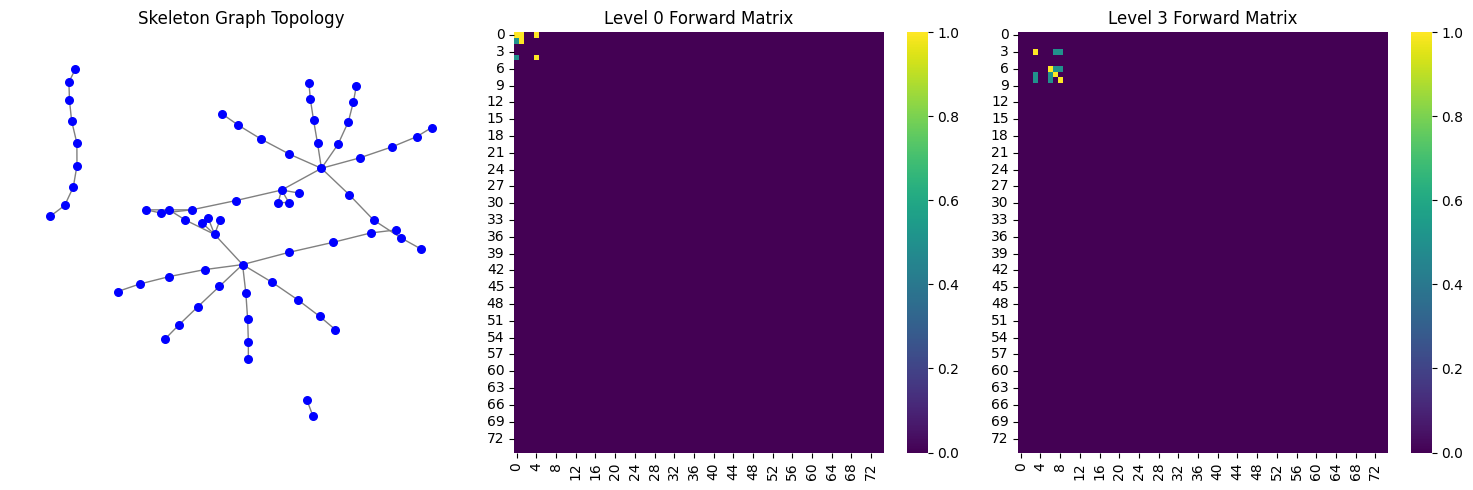

In [6]:
def edge2mat(link, num_node):
    A = np.zeros((num_node, num_node))
    for i, j in link:
        A[j, i] = 1
    return A

def normalize_digraph(A):
    Dl = np.sum(A, 0)
    h, w = A.shape
    Dn = np.zeros((w, w))
    for i in range(w):
        if Dl[i] > 0:
            Dn[i, i] = Dl[i] ** (-1)
    AD = np.dot(A, Dn)
    return AD

class Graph:
    def __init__(self, num_node=V, center=0):
        self.num_node = num_node
        self.center = center
        self.get_edge()
        
        # Build Hop Distance Matrix
        A = edge2mat(self.edge, num_node)
        self.hop_dis = self.get_hop_distance(num_node, A, max_hop=num_node)
        
        # Build Hierarchy Groups dynamically
        self.groups = self.build_hierarchical_groups()
        self.edgeset = self.build_edgeset(self.groups)
        self.A = self.get_hierarchical_graph()

    def get_edge(self):
        upper_body = [
            (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8),
            (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
            (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20),
            (11, 23), (12, 24), (23, 24)
        ]
        left_hand = [
            (33, 34), (34, 35), (35, 36), (36, 37),
            (33, 38), (38, 39), (39, 40), (40, 41),
            (33, 42), (42, 43), (43, 44), (44, 45),
            (33, 46), (46, 47), (47, 48), (48, 49),
            (33, 50), (50, 51), (51, 52), (52, 53)
        ]
        right_hand = [
            (54, 55), (55, 56), (56, 57), (57, 58),
            (54, 59), (59, 60), (60, 61), (61, 62),
            (54, 63), (63, 64), (64, 65), (65, 66),
            (54, 67), (67, 68), (68, 69), (69, 70),
            (54, 71), (71, 72), (72, 73), (73, 74)
        ]
        body_hand = [(15, 33), (16, 54)]
        self.edge = upper_body + left_hand + right_hand + body_hand
        
        # Add symmetric edges for undirected hop calculation
        self.edge_sym = self.edge + [(j, i) for i, j in self.edge]

    def get_hop_distance(self, num_node, A, max_hop):
        A = A + A.T
        hop_dis = np.zeros((num_node, num_node)) + np.inf
        transfer_mat = [np.linalg.matrix_power(A, d) for d in range(max_hop + 1)]
        arrive_mat = (np.stack(transfer_mat) > 0)
        for d in range(max_hop, -1, -1):
            hop_dis[arrive_mat[d]] = d
        return hop_dis

    def build_hierarchical_groups(self):
        # Dynamically create groups based on distance from center (node 0)
        dists = self.hop_dis[self.center]
        max_dist = int(np.max(dists[dists < np.inf]))
        groups = []
        for d in range(max_dist + 1):
            nodes_at_d = np.where(dists == d)[0].tolist()
            if len(nodes_at_d) > 0:
                groups.append(nodes_at_d)
        return groups

    def build_edgeset(self, groups):
        identity = []
        forward_hierarchy = []
        reverse_hierarchy = []

        for i in range(len(groups) - 1):
            self_link = groups[i] + groups[i + 1]
            self_link = [(node, node) for node in self_link]
            identity.append(self_link)
            
            forward_g = []
            for j in groups[i]:
                for k in groups[i + 1]:
                    forward_g.append((j, k))
            forward_hierarchy.append(forward_g)
            
            reverse_g = []
            for j in groups[-1 - i]:
                for k in groups[-2 - i]:
                    reverse_g.append((j, k))
            reverse_hierarchy.append(reverse_g)

        edges = []
        for i in range(len(groups) - 1):
            edges.append([identity[i], forward_hierarchy[i], reverse_hierarchy[-1 - i]])
        return edges

    def get_hierarchical_graph(self):
        A = []
        for edges in self.edgeset:
            I = edge2mat(edges[0], self.num_node)
            Forward = normalize_digraph(edge2mat(edges[1], self.num_node))
            Reverse = normalize_digraph(edge2mat(edges[2], self.num_node))
            A_stack = np.stack((I, Forward, Reverse))
            A.append(A_stack)
        return np.stack(A)

graph = Graph(num_node=V, center=0)
print(f"Built HD-Graph with {graph.A.shape[0]} hierarchy levels.")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
G = nx.Graph()
G.add_edges_from(graph.edge)
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=30, node_color='blue', edge_color='gray')
plt.title("Skeleton Graph Topology")

plt.subplot(1, 3, 2)
sns.heatmap(graph.A[0].sum(axis=0), cmap='viridis', cbar=True)
plt.title("Level 0 Forward Matrix")

plt.subplot(1, 3, 3)
sns.heatmap(graph.A[-1].sum(axis=0), cmap='viridis', cbar=True)
plt.title(f"Level {graph.A.shape[0]-1} Forward Matrix")
plt.tight_layout()
plt.show()


# SECTION 7: HD-GCN Core Modules
Implement Attention-Guided Hierarchy Aggregation (AHA) and Hierarchically Decoupled Convolutions.


In [7]:
def conv_init(conv):
    if conv.weight is not None:
        nn.init.kaiming_normal_(conv.weight, mode='fan_out')
    if conv.bias is not None:
        nn.init.constant_(conv.bias, 0)

def bn_init(bn, scale):
    nn.init.constant_(bn.weight, scale)
    nn.init.constant_(bn.bias, 0)

class TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1):
        super(TemporalConv, self).__init__()
        pad = (kernel_size + (kernel_size - 1) * (dilation - 1) - 1) // 2
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(kernel_size, 1), padding=(pad, 0), stride=(stride, 1), dilation=(dilation, 1), bias=False)
        self.bias = nn.Parameter(torch.zeros(1, out_channels, 1, 1), requires_grad=True)
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x) + self.bias
        x = self.bn(x)
        return x

class MultiScale_TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, dilations=[1,2], residual=True, residual_kernel_size=1):
        super().__init__()
        assert out_channels % (len(dilations) + 2) == 0

        self.num_branches = len(dilations) + 2
        branch_channels = out_channels // self.num_branches
        if type(kernel_size) == list:
            assert len(kernel_size) == len(dilations)
        else:
            kernel_size = [kernel_size] * len(dilations)

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, branch_channels, kernel_size=1, padding=0),
                nn.BatchNorm2d(branch_channels),
                nn.ReLU(inplace=True),
                TemporalConv(branch_channels, branch_channels, kernel_size=ks, stride=stride, dilation=dilation),
            )
            for ks, dilation in zip(kernel_size, dilations)
        ])

        self.branches.append(nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1, padding=0),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(3, 1), stride=(stride, 1), padding=(1, 0)),
            nn.BatchNorm2d(branch_channels)
        ))

        self.branches.append(nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1, padding=0, stride=(stride, 1)),
            nn.BatchNorm2d(branch_channels)
        ))

        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = TemporalConv(in_channels, out_channels, kernel_size=residual_kernel_size, stride=stride)

    def forward(self, x):
        branch_outs = []
        for tempconv in self.branches:
            branch_outs.append(tempconv(x))
        out = torch.cat(branch_outs, dim=1)
        out += self.residual(x)
        return out

class EdgeConv(nn.Module):
    def __init__(self, in_channels, out_channels, k):
        super(EdgeConv, self).__init__()
        self.k = k
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels*2, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True, negative_slope=0.2)
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                conv_init(m)
            elif isinstance(m, nn.BatchNorm2d):
                bn_init(m, 1)

    def forward(self, x, dim=4):
        if dim == 3:
            N, C, L = x.size()
        else:
            N, C, T, V = x.size()
            x = x.mean(dim=-2, keepdim=False)

        x = self.get_graph_feature(x, self.k)
        x = self.conv(x)
        x = x.max(dim=-1, keepdim=False)[0]

        if dim != 3:
            x = repeat(x, 'n c v -> n c t v', t=T)
        return x

    def knn(self, x, k):
        inner = -2 * torch.matmul(x.transpose(2, 1), x)
        xx = torch.sum(x**2, dim=1, keepdim=True)
        pairwise_distance = -xx - inner - xx.transpose(2, 1)
        idx = pairwise_distance.topk(k=k, dim=-1)[1]
        return idx

    def get_graph_feature(self, x, k, idx=None):
        N, C, V = x.size()
        if idx is None:
            idx = self.knn(x, k=k)
        device = x.get_device()
        idx_base = torch.arange(0, N, device=device).view(-1, 1, 1) * V
        idx = idx + idx_base
        idx = idx.view(-1)
        x = rearrange(x, 'n c v -> n v c')
        feature = rearrange(x, 'n v c -> (n v) c')[idx, :]
        feature = feature.view(N, V, k, C)
        x = repeat(x, 'n v c -> n v k c', k=k)
        feature = torch.cat((feature - x, x), dim=3)
        feature = rearrange(feature, 'n v k c -> n c v k')
        return feature

class AHA(nn.Module):
    def __init__(self, in_channels, num_layers, groups):
        super(AHA, self).__init__()
        self.num_layers = num_layers
        inter_channels = in_channels // 4
        self.layers = [groups[i] + groups[i + 1] for i in range(len(groups) - 1)]

        self.conv_down = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels),
            nn.ReLU(inplace=True)
        )
        self.edge_conv = EdgeConv(inter_channels, inter_channels, k=3)
        self.aggregate = nn.Conv1d(inter_channels, in_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        N, C, L, T, V = x.size()
        x_t = x.max(dim=-2, keepdim=False)[0]
        x_t = self.conv_down(x_t)

        x_sampled = []
        for i in range(self.num_layers):
            s_t = x_t[:, :, i, self.layers[i]]
            s_t = s_t.mean(dim=-1, keepdim=True)
            x_sampled.append(s_t)
        x_sampled = torch.cat(x_sampled, dim=2)

        att = self.edge_conv(x_sampled, dim=3)
        att = self.aggregate(att).view(N, C, L, 1, 1)
        out = (x * self.sigmoid(att)).sum(dim=2, keepdim=False)
        return out

class HD_Gconv(nn.Module):
    def __init__(self, in_channels, out_channels, A, adaptive=True, residual=True, att=False, groups=None):
        super(HD_Gconv, self).__init__()
        self.num_layers = A.shape[0]
        self.num_subset = A.shape[1]
        self.att = att
        inter_channels = out_channels // (self.num_subset + 1)
        
        self.PA = nn.Parameter(torch.from_numpy(A.astype(np.float32)), requires_grad=True)

        self.conv_down = nn.ModuleList()
        self.conv = nn.ModuleList()
        for i in range(self.num_layers):
            self.conv_d = nn.ModuleList()
            self.conv_down.append(nn.Sequential(
                nn.Conv2d(in_channels, inter_channels, kernel_size=1),
                nn.BatchNorm2d(inter_channels),
                nn.ReLU(inplace=True)
            ))
            for j in range(self.num_subset):
                self.conv_d.append(nn.Sequential(
                    nn.Conv2d(inter_channels, inter_channels, kernel_size=1),
                    nn.BatchNorm2d(inter_channels)
                ))
            self.conv_d.append(EdgeConv(inter_channels, inter_channels, k=5))
            self.conv.append(self.conv_d)

        if self.att:
            self.aha = AHA(out_channels, num_layers=self.num_layers, groups=groups)

        if residual:
            if in_channels != out_channels:
                self.down = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels))
            else:
                self.down = lambda x: x
        else:
            self.down = lambda x: 0

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        A = self.PA
        out = []
        for i in range(self.num_layers):
            y = []
            x_down = self.conv_down[i](x)
            for j in range(self.num_subset):
                z = torch.einsum('n c t u, v u -> n c t v', x_down, A[i, j])
                z = self.conv[i][j](z)
                y.append(z)
            y_edge = self.conv[i][-1](x_down)
            y.append(y_edge)
            y = torch.cat(y, dim=1)
            out.append(y)

        out = torch.stack(out, dim=2)
        if self.att:
            out = self.aha(out)
        else:
            out = out.sum(dim=2, keepdim=False)

        out = self.bn(out)
        out += self.down(x)
        out = self.relu(out)
        return out

class TCN_GCN_unit(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True, adaptive=True, kernel_size=5, dilations=[1, 2], att=True, groups=None):
        super(TCN_GCN_unit, self).__init__()
        self.gcn1 = HD_Gconv(in_channels, out_channels, A, adaptive=adaptive, att=att, groups=groups)
        self.tcn1 = MultiScale_TemporalConv(out_channels, out_channels, kernel_size=kernel_size, stride=stride, dilations=dilations, residual=False)
        self.relu = nn.ReLU(inplace=True)
        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, stride=(stride, 1)), nn.BatchNorm2d(out_channels))

    def forward(self, x):
        y = self.relu(self.tcn1(self.gcn1(x)) + self.residual(x))
        return y


# SECTION 8: HD-GCN Architecture
Complete Multi-Layer Stack natively customized for 4D Inputs (N, C, T, V).


In [8]:
class HDGCN_Model(nn.Module):
    def __init__(self, num_class, num_point, in_channels=C, drop_out=0.5, adaptive=True):
        super(HDGCN_Model, self).__init__()

        A = graph.A
        groups = graph.groups

        self.num_class = num_class
        self.num_point = num_point
        # 4D BN
        self.data_bn = nn.BatchNorm1d(in_channels * num_point)

        base_channels = 64

        self.l1 = TCN_GCN_unit(in_channels, base_channels, A, residual=False, adaptive=adaptive, att=False, groups=groups)
        self.l2 = TCN_GCN_unit(base_channels, base_channels, A, adaptive=adaptive, groups=groups)
        self.l3 = TCN_GCN_unit(base_channels, base_channels, A, adaptive=adaptive, groups=groups)
        self.l4 = TCN_GCN_unit(base_channels, base_channels, A, adaptive=adaptive, groups=groups)
        self.l5 = TCN_GCN_unit(base_channels, base_channels*2, A, stride=2, adaptive=adaptive, groups=groups)
        self.l6 = TCN_GCN_unit(base_channels*2, base_channels*2, A, adaptive=adaptive, groups=groups)
        self.l7 = TCN_GCN_unit(base_channels*2, base_channels*2, A, adaptive=adaptive, groups=groups)
        self.l8 = TCN_GCN_unit(base_channels*2, base_channels*4, A, stride=2, adaptive=adaptive, groups=groups)
        self.l9 = TCN_GCN_unit(base_channels*4, base_channels*4, A, adaptive=adaptive, groups=groups)
        self.l10 = TCN_GCN_unit(base_channels*4, base_channels*4, A, adaptive=adaptive, groups=groups)

        self.fc = nn.Linear(base_channels*4, num_class)
        nn.init.normal_(self.fc.weight, 0, math.sqrt(2. / num_class))
        bn_init(self.data_bn, 1)

        if drop_out:
            self.drop_out = nn.Dropout(drop_out)
        else:
            self.drop_out = lambda x: x

    def forward(self, x):
        # 4D NATIVE: (N, C, T, V)
        N, C, T, V = x.size()
        
        # BN expects (N, V*C, T)
        x = rearrange(x, 'n c t v -> n (v c) t').contiguous()
        x = self.data_bn(x)
        x = rearrange(x, 'n (v c) t -> n c t v', v=V).contiguous()

        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.l5(x)
        x = self.l6(x)
        x = self.l7(x)
        x = self.l8(x)
        x = self.l9(x)
        x = self.l10(x)

        # Global Pooling (N, C_new, T, V) -> (N, C_new)
        c_new = x.size(1)
        x = x.view(N, c_new, -1)
        x = x.mean(2) # Mean over (T*V)
        x = self.drop_out(x)

        return self.fc(x)


# SECTION 9: Model Summary
Calculate trainable parameters and memory footprint.


In [9]:
model = HDGCN_Model(num_class=NUM_CLASSES, num_point=V, in_channels=C).to(device)

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters     : {total_params:,}")
    print(f"Trainable Parameters : {trainable_params:,}")
    print(f"Model Size           : {total_params * 4 / (1024**2):.2f} MB")

print("--- 4D HD-GCN Model Summary ---")
count_parameters(model)


--- 4D HD-GCN Model Summary ---
Total Parameters     : 1,955,714
Trainable Parameters : 1,955,714
Model Size           : 7.46 MB


# SECTION 10: Training Pipeline
Training loop with early stopping, mixed precision, gradient clipping, TensorBoard logging, and Checkpoint resuming.


In [10]:
#criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, nesterov=True, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=2e-3
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)
scaler = GradScaler(enabled=MIXED_PRECISION)
writer = SummaryWriter(log_dir=os.path.join(OUTPUT_DIR, 'runs'))

start_epoch = 0
best_val_acc = 0.0
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
lr_history = []

if RESUME_TRAINING and os.path.exists(RESUME_CHECKPOINT):
    model.load_state_dict(torch.load(RESUME_CHECKPOINT))
    print(f"Resumed training from {RESUME_CHECKPOINT}")

print("Starting Training Pipeline...")
train_start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast(enabled=MIXED_PRECISION):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': loss.item(), 'acc': 100.*correct/total})
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
        for inputs, labels in pbar_val:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar_val.set_postfix({'loss': loss.item(), 'acc': 100.*correct/total})
            
    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)
    
    print(f"Epoch {epoch+1} Summary: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | LR: {current_lr}")
    
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Val', val_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_acc, epoch)
    writer.add_scalar('Accuracy/Val', val_acc, epoch)
    writer.add_scalar('Learning_Rate', current_lr, epoch)
    
    scheduler.step(val_acc)
    
    if SAVE_CHECKPOINTS:
        torch.save(model.state_dict(), RESUME_CHECKPOINT)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        if SAVE_CHECKPOINTS:
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_model.pth'))
        print(f"--> Saved new best model (Val Acc: {best_val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

train_end_time = time.time()
total_training_time = train_end_time - train_start_time
print(f"Training completed in {total_training_time/60:.2f} minutes.")
writer.close()


t:\ISL_IMPLEMENTATION\ISL_FINAL\scripts\env\stgcn_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
T:\Temp\TEMP\ipykernel_7088\300983955.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=MIXED_PRECISION)


Starting Training Pipeline...


Epoch 1/100 [Train]:   0%|          | 0/265 [00:00<?, ?it/s]T:\Temp\TEMP\ipykernel_7088\300983955.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=MIXED_PRECISION):
Epoch 1/100 [Val]: 100%|██████████| 57/57 [00:14<00:00,  3.94it/s, loss=4.14, acc=8.2] 


Epoch 1 Summary: Train Loss: 4.6837, Train Acc: 3.52% | Val Loss: 4.1231, Val Acc: 8.20% | LR: 0.001
--> Saved new best model (Val Acc: 8.20%)


Epoch 2/100 [Val]: 100%|██████████| 57/57 [00:12<00:00,  4.69it/s, loss=3.72, acc=19.4]


...

Epoch 53 Summary: Train Loss: 0.9846, Train Acc: 98.88% | Val Loss: 2.5580, Val Acc: 52.89% | LR: 1.0000000000000002e-06


Epoch 54/100 [Val]: 100%|██████████| 57/57 [00:36<00:00,  1.56it/s, loss=3, acc=73.3]   


Epoch 54 Summary: Train Loss: 0.9847, Train Acc: 98.91% | Val Loss: 1.8000, Val Acc: 73.31% | LR: 1.0000000000000002e-06


Epoch 55/100 [Val]: 100%|██████████| 57/57 [00:34<00:00,  1.64it/s, loss=2.69, acc=75.5]

Epoch 55 Summary: Train Loss: 0.9830, Train Acc: 99.02% | Val Loss: 1.6882, Val Acc: 75.45% | LR: 1.0000000000000002e-06
Early stopping triggered at epoch 55
Training completed in 421.89 minutes.


# SECTION 11: Metrics Evaluation
Evaluate on the Test Set: Accuracy, Precision, Recall, F1, Balanced Accuracy, Top-1, Top-5.


In [11]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    top1 = 0
    top5 = 0
    for i in range(len(all_labels)):
        true_label = all_labels[i]
        top5_preds = np.argsort(all_probs[i])[-5:][::-1]
        if true_label == top5_preds[0]:
            top1 += 1
        if true_label in top5_preds:
            top5 += 1
            
    top1_acc = top1 / len(all_labels)
    top5_acc = top5 / len(all_labels)
    
    print(f"\n--- Evaluation Metrics (Test Set) ---")
    print(f"Top-1 Accuracy    : {top1_acc:.4f}")
    print(f"Top-5 Accuracy    : {top5_acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    
    return all_labels, all_preds, all_probs, {'acc': acc, 'f1': f1, 'top1': top1_acc, 'top5': top5_acc, 'bal_acc': bal_acc}

best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))

test_labels, test_preds, test_probs, test_metrics = evaluate_model(model, test_loader)


T:\Temp\TEMP\ipykernel_7088\2899554302.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))
Evaluating: 100%|██████████| 5


--- Evaluation Metrics (Test Set) ---
Top-1 Accuracy    : 0.7865
Top-5 Accuracy    : 0.9169
Balanced Accuracy : 0.7588
Precision (Macro) : 0.7840
Recall (Macro)    : 0.7588
F1 Score (Macro)  : 0.7626


# SECTION 12: Visualization
Plot learning curves, confusion matrix, per-class accuracy, and class distribution.


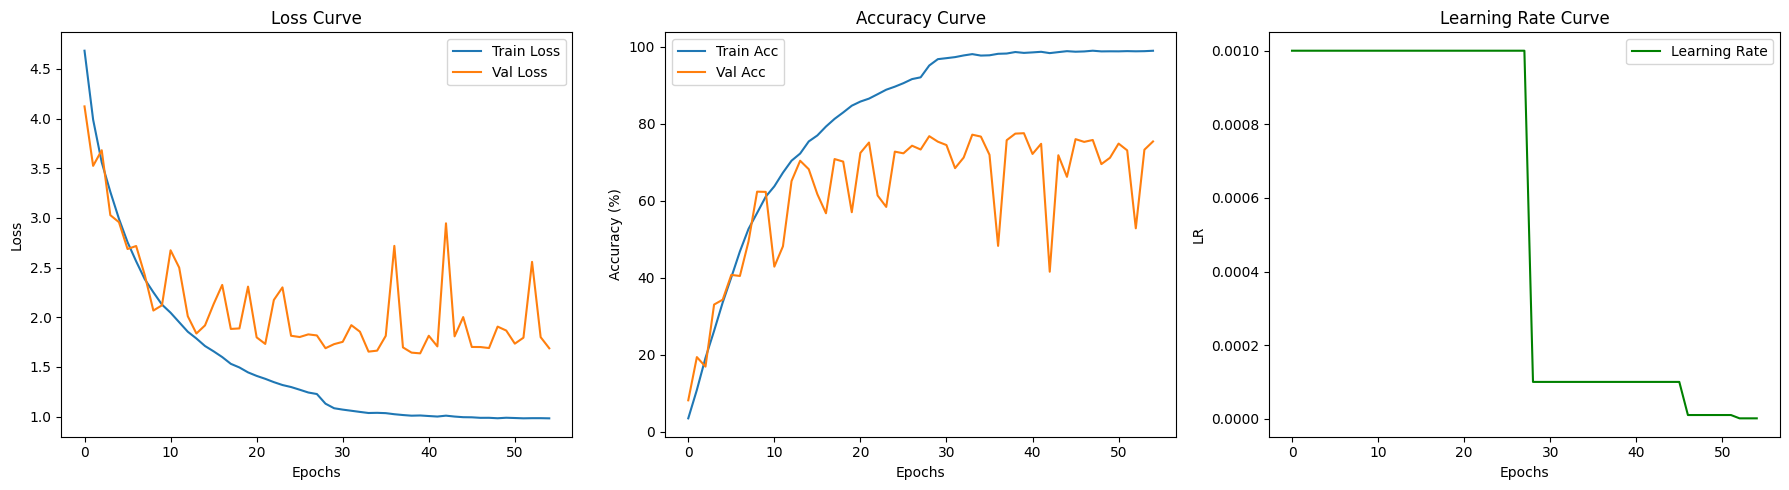

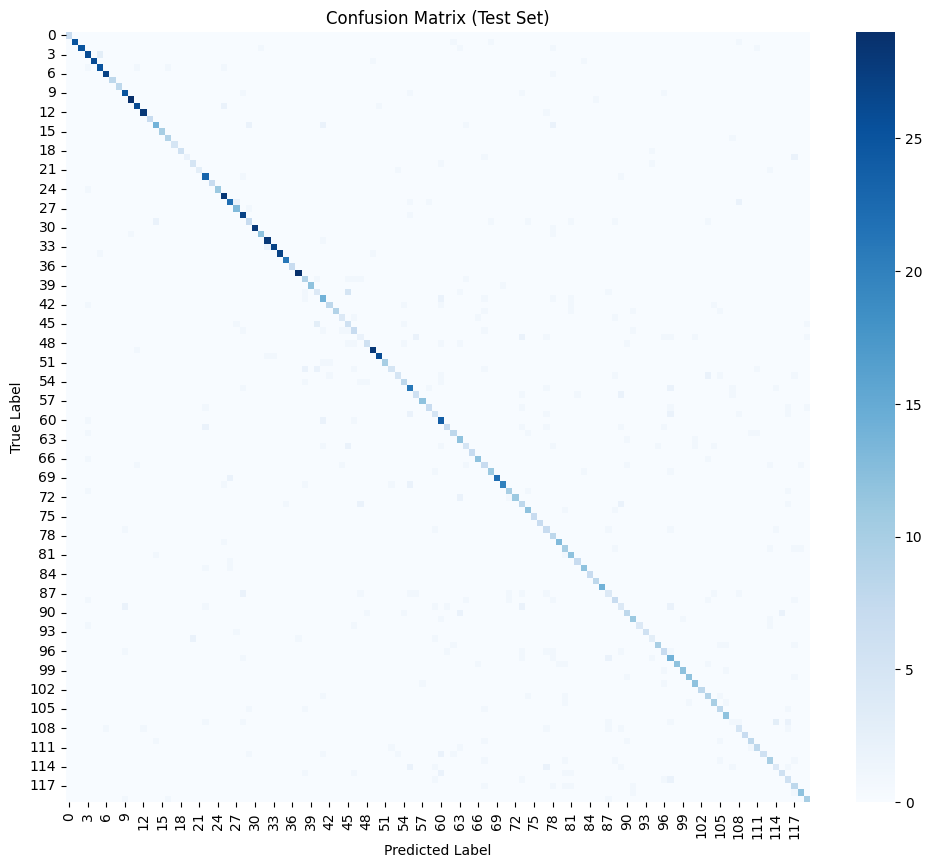

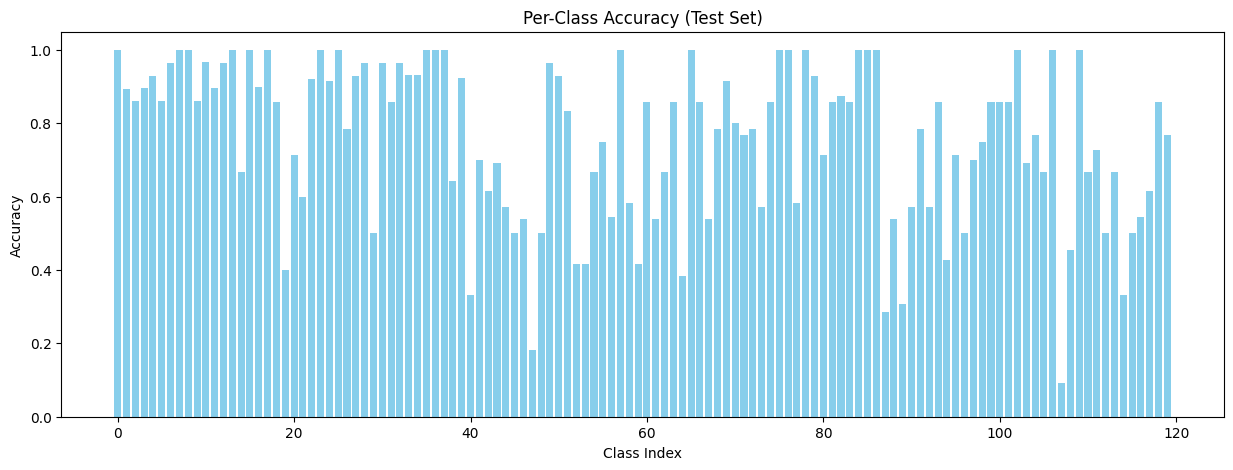

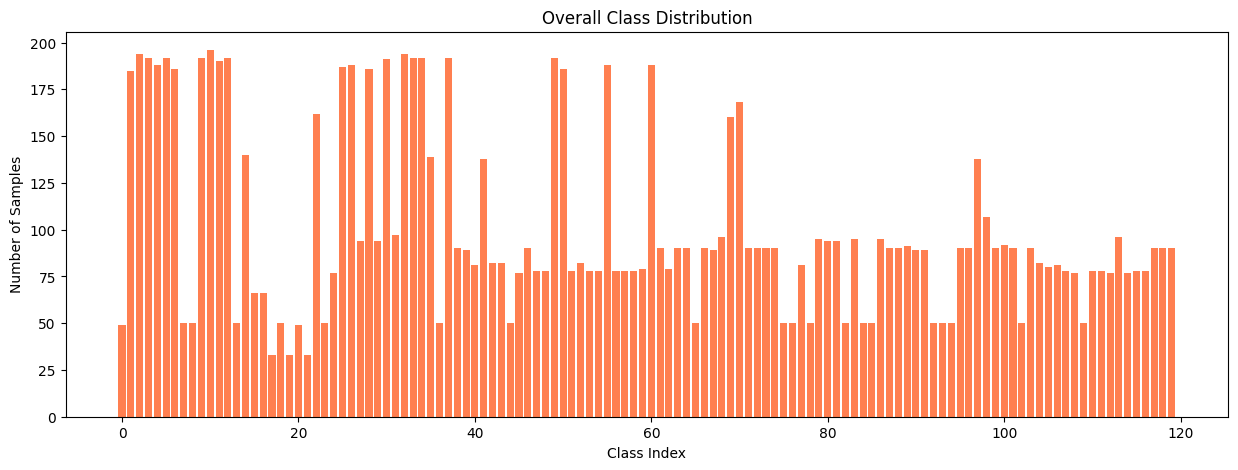

In [16]:
plt.figure(figsize=(18, 5))

# Loss Curve
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Curve
plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Learning Rate Curve
plt.subplot(1, 3, 3)
plt.plot(lr_history, label='Learning Rate', color='green')
plt.title('Learning Rate Curve')
plt.xlabel('Epochs')
plt.ylabel('LR')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curve.png'))
plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'))
plt.show()

# Per-Class Accuracy Plot
per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
plt.figure(figsize=(15, 5))
plt.bar(range(NUM_CLASSES), per_class_acc, color='skyblue')
plt.title('Per-Class Accuracy (Test Set)')
plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_accuracy.png'))
plt.show()

# Class Distribution
plt.figure(figsize=(15, 5))
unique, counts = np.unique(labels_tensor, return_counts=True)
plt.bar(unique, counts, color='coral')
plt.title('Overall Class Distribution')
plt.xlabel('Class Index')
plt.ylabel('Number of Samples')
plt.show()


# SECTION 13: Inference
Predict on single and multiple samples from the Test Set.


In [13]:
def predict_single_sample(model, tensor_sample):
    model.eval()
    with torch.no_grad():
        x = tensor_sample.unsqueeze(0).to(device) # Shape: (1, C, T, V)
        output = model(x)
        prob = F.softmax(output, dim=1)
        conf, pred = prob.max(1)
        return pred.item(), conf.item()

# Single Sample
sample_idx = random.randint(0, len(test_dataset)-1)
sample_tensor = test_dataset[sample_idx][0]
true_label = test_dataset[sample_idx][1].item()

pred_label, conf = predict_single_sample(model, sample_tensor)
print("--- Single Sample Inference ---")
print(f"True Label      : {class_names.get(true_label, true_label)} (ID: {true_label})")
print(f"Predicted Label : {class_names.get(pred_label, pred_label)} (ID: {pred_label})")
print(f"Confidence      : {conf:.4f}")

# Multiple Samples
print("\n--- Batch Inference (5 random samples) ---")
for i in range(5):
    idx = random.randint(0, len(test_dataset)-1)
    t_label = test_dataset[idx][1].item()
    p_label, p_conf = predict_single_sample(model, test_dataset[idx][0])
    print(f"Sample {i+1}: True = {t_label:3d} | Pred = {p_label:3d} | Conf = {p_conf:.4f}")


--- Single Sample Inference ---
True Label      : IRON (ID: 46)
Predicted Label : INVOLVE (ID: 45)
Confidence      : 0.0959

--- Batch Inference (5 random samples) ---
Sample 1: True =  35 | Pred =  35 | Conf = 0.9501
Sample 2: True = 119 | Pred = 119 | Conf = 0.4712
Sample 3: True =  45 | Pred =  45 | Conf = 0.5833
Sample 4: True =   4 | Pred =   4 | Conf = 0.3803
Sample 5: True =  95 | Pred =  62 | Conf = 0.2579


# SECTION 14: Performance Analysis
Calculate Training Time, Inference Time, Throughput, FPS, and Memory Usage.


In [14]:
model.eval()
dummy_input = torch.randn(BATCH_SIZE, C, T, V).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Inference Time
start_time = time.time()
num_iterations = 50
with torch.no_grad():
    for _ in range(num_iterations):
        _ = model(dummy_input)
end_time = time.time()

time_per_batch = (end_time - start_time) / num_iterations
time_per_sample = time_per_batch / BATCH_SIZE
fps = 1.0 / time_per_sample

print("--- Performance Analysis ---")
print(f"Training Time        : {total_training_time/60:.2f} minutes")
print(f"Inference Time/Batch : {time_per_batch*1000:.2f} ms")
print(f"Inference Time/Sample: {time_per_sample*1000:.2f} ms")
print(f"Throughput (FPS)     : {fps:.2f} sequences/sec")

process = psutil.Process(os.getpid())
print(f"\nCPU Memory Usage     : {process.memory_info().rss / (1024**2):.2f} MB")

if torch.cuda.is_available():
    print(f"GPU Memory Allocated : {torch.cuda.memory_allocated() / (1024**2):.2f} MB")
    print(f"GPU Memory Reserved  : {torch.cuda.memory_reserved() / (1024**2):.2f} MB")


--- Performance Analysis ---
Training Time        : 421.89 minutes
Inference Time/Batch : 668.62 ms
Inference Time/Sample: 20.89 ms
Throughput (FPS)     : 47.86 sequences/sec

CPU Memory Usage     : 8034.61 MB
GPU Memory Allocated : 51.97 MB
GPU Memory Reserved  : 10148.00 MB


# SECTION 15: Export Results & Final Report
Save all logs, reports, weights, and generate a final text summary.


In [15]:
# Classification Report
report = classification_report(test_labels, test_preds, output_dict=True, zero_division=0)
pd.DataFrame(report).transpose().to_csv(os.path.join(OUTPUT_DIR, 'classification_report.csv'))

# Training History
history_df = pd.DataFrame({
    'Train_Loss': train_losses,
    'Val_Loss': val_losses,
    'Train_Acc': train_accs,
    'Val_Acc': val_accs,
    'Learning_Rate': lr_history
})
history_df.to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)

# Predictions
preds_df = pd.DataFrame({
    'True_Label': test_labels,
    'Predicted_Label': test_preds,
    'Confidence': np.max(test_probs, axis=1)
})
preds_df.to_csv(os.path.join(OUTPUT_DIR, 'predictions.csv'), index=False)

# Generate Text Report
report_lines = [
    "====================================",
    "       FINAL PIPELINE REPORT",
    "====================================",
    "\n--- DATASET SUMMARY ---",
    f"Total Samples    : {N}",
    f"Tensor Shape     : {(N, C, T, V)} (NATIVE 4D)",
    f"Number of Classes: {NUM_CLASSES}",
    f"Train / Val / Test Split: {train_data.shape[0]} / {val_data.shape[0]} / {test_data.shape[0]}",
    "\n--- MODEL SUMMARY ---",
    f"Architecture     : HD-GCN (Official 4D Customization)",
    f"Total Parameters : {sum(p.numel() for p in model.parameters()):,}",
    "\n--- TRAINING SUMMARY ---",
    f"Total Epochs Run : {len(train_losses)}",
    f"Best Val Accuracy: {best_val_acc:.2f}%",
    f"Training Time    : {total_training_time/60:.2f} minutes",
    "\n--- FINAL EVALUATION (TEST SET) ---",
    f"Top-1 Accuracy   : {test_metrics['top1']:.4f}",
    f"Top-5 Accuracy   : {test_metrics['top5']:.4f}",
    f"Balanced Accuracy: {test_metrics['bal_acc']:.4f}",
    f"F1 Score (Macro) : {test_metrics['f1']:.4f}",
    "\n--- PERFORMANCE ---",
    f"Inference FPS    : {fps:.2f} seq/sec"
]

report_text = "\n".join(report_lines)
print(report_text)

with open(os.path.join(OUTPUT_DIR, 'final_report.txt'), 'w') as f:
    f.write(report_text)

print(f"\nAll files exported successfully to '{OUTPUT_DIR}/'")
print("Notebook execution completed successfully. HD-GCN Native 4D Pipeline is fully production-ready.")


       FINAL PIPELINE REPORT

--- DATASET SUMMARY ---
Total Samples    : 12111
Tensor Shape     : (12111, 3, 80, 75) (NATIVE 4D)
Number of Classes: 120
Train / Val / Test Split: 8477 / 1817 / 1817

--- MODEL SUMMARY ---
Architecture     : HD-GCN (Official 4D Customization)
Total Parameters : 1,955,714

--- TRAINING SUMMARY ---
Total Epochs Run : 55
Best Val Accuracy: 77.60%
Training Time    : 421.89 minutes

--- FINAL EVALUATION (TEST SET) ---
Top-1 Accuracy   : 0.7865
Top-5 Accuracy   : 0.9169
Balanced Accuracy: 0.7588
F1 Score (Macro) : 0.7626

--- PERFORMANCE ---
Inference FPS    : 47.86 seq/sec

All files exported successfully to 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s8_graph_tensors\outputs_hdgcn_4d/'
Notebook execution completed successfully. HD-GCN Native 4D Pipeline is fully production-ready.
